In [2]:
from google.colab import drive, files

In [3]:
import os
import gc
import glob
import shutil

In [4]:
from PIL import Image

In [5]:
import numpy as np

In [6]:
import cv2

In [7]:
%pip install torch diffusers torchvision -q
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

from diffusers import StableDiffusionPipeline, DDPMScheduler

cuda


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [8]:
from tqdm import tqdm

# Подготовка данных

In [8]:
drive.mount('drive')

!mkdir -p selfies
!mkdir -p processed_selfies

!mkdir -p drive/MyDrive/my_face_model

Mounted at drive


In [10]:
IMAGE_DIR = "/content/selfies"
PROCESSED_IMAGE_DIR = "/content/processed_selfies"
MODEL_DIR = "/content/drive/MyDrive/my_face_model"

In [10]:
print("Upload your 20 selfies (JPEG/PNG):")
uploaded = files.upload()

for filename, content in uploaded.items():
    with open(IMAGE_DIR + f"/{filename}", 'wb') as f:
        f.write(content)

print(f"Uploaded {len(uploaded)} images to {IMAGE_DIR}")

Upload your 20 selfies (JPEG/PNG):


Saving 20260404_160723.JPG to 20260404_160723.JPG
Saving 20260404_160720.JPG to 20260404_160720.JPG
Saving 20260404_160717.JPG to 20260404_160717.JPG
Saving 20260404_160712.JPG to 20260404_160712.JPG
Saving 20260404_152750(1).JPG to 20260404_152750(1).JPG
Saving 20260404_152750.JPG to 20260404_152750.JPG
Saving 20260404_152716(1).JPG to 20260404_152716(1).JPG
Saving 20260404_152716.JPG to 20260404_152716.JPG
Saving 20260404_152711.JPG to 20260404_152711.JPG
Saving 20260404_152704.JPG to 20260404_152704.JPG
Saving 20260404_152658.JPG to 20260404_152658.JPG
Saving 20260404_152648.JPG to 20260404_152648.JPG
Saving 20260404_152640.JPG to 20260404_152640.JPG
Saving 20260404_152632.JPG to 20260404_152632.JPG
Saving 20260404_152620.JPG to 20260404_152620.JPG
Saving 20260404_152604.JPG to 20260404_152604.JPG
Saving 20260404_152549.JPG to 20260404_152549.JPG
Saving 20260404_152523.JPG to 20260404_152523.JPG
Saving 20260404_152504.JPG to 20260404_152504.JPG
Saving 20260404_152439.JPG to 20260404

In [11]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

successful = 0
for img_path in glob.glob(IMAGE_DIR + "/*.*"):
    img = cv2.imread(img_path)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    if len(faces) > 0:
        x, y, w, h = faces[0]

        margin = int(0.2 * max(w, h))
        x = max(0, x - margin)
        y = max(0, y - margin)
        w = min(img.shape[1] - x, w + 2*margin)
        h = min(img.shape[0] - y, h + 2*margin)

        face = img[y:y+h, x:x+w]
        face = cv2.resize(face, (512, 512))

        cv2.imwrite(f"{PROCESSED_IMAGE_DIR}/{os.path.basename(img_path)}", face)
        successful += 1
        print(f"{os.path.basename(img_path)}")
    else:
        print(f"No face: {os.path.basename(img_path)}")

print(f"\nParsed {successful} photos")

20260404_152632.JPG
20260404_152620.JPG
20260404_152640.JPG
20260404_152658.JPG
20260404_152604.JPG
20260404_152504.JPG
20260404_152716(1).JPG
20260404_152648.JPG
20260404_160717.JPG
20260404_160723.JPG
20260404_160720.JPG
20260404_152711.JPG
20260404_152750(1).JPG
20260404_152549.JPG
20260404_152704.JPG
20260404_152750.JPG
20260404_160712.JPG
20260404_152523.JPG
20260404_152716.JPG
20260404_152439.JPG

Parsed 20 photos


In [11]:
class ImageDataset(Dataset):
    def __init__(self):
        self.images = [f for f in os.listdir(PROCESSED_IMAGE_DIR)]
        self.transform = transforms.Compose([
            transforms.Resize(512),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(f"{PROCESSED_IMAGE_DIR}/{self.images[idx]}").convert('RGB')
        return self.transform(img)


dataloader = DataLoader(ImageDataset(), batch_size=1, shuffle=True)
print(len(dataloader))

20


# Модель

In [12]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float32
).to(DEVICE)

for param in pipe.unet.parameters():
    param.requires_grad = False
for name, param in pipe.unet.named_parameters():
    if "attn2" in name:
        param.requires_grad = True
print(f"Trainable params: {sum(p.numel() for p in pipe.unet.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 43,962,560


In [13]:
EPOCHS = 15

optimizer = torch.optim.AdamW(
    [p for p in pipe.unet.parameters() if p.requires_grad],
    lr=1e-4
)
noise_scheduler = DDPMScheduler.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="scheduler")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [14]:
TOKEN = "olegmamontov"

print(f"Training on {len(dataloader)} images for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    for step, image in enumerate(dataloader):
        image = image.to(DEVICE)

        latents = pipe.vae.encode(image).latent_dist.sample() * 0.18215

        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, 1000, (1,), device=DEVICE)
        noisy = noise_scheduler.add_noise(latents, noise, timesteps)

        text = pipe.tokenizer([f"a photo of {TOKEN} person"], return_tensors="pt", padding=True).input_ids.to(DEVICE)
        text_embed = pipe.text_encoder(text)[0]

        noise_pred = pipe.unet(noisy, timesteps, text_embed).sample

        loss = torch.nn.functional.mse_loss(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 10 == 0:
            print(f"Epoch {epoch}, Step {step}, Loss: {loss.item():.4f}")

pipe.save_pretrained(MODEL_DIR)
print(f"Model saved to {MODEL_DIR}")

Training on 20 images for 15 epochs...
Epoch 0, Step 0, Loss: 0.1736
Epoch 0, Step 10, Loss: 0.0022
Epoch 1, Step 0, Loss: 0.0221
Epoch 1, Step 10, Loss: 0.0109
Epoch 2, Step 0, Loss: 0.0390
Epoch 2, Step 10, Loss: 0.0082
Epoch 3, Step 0, Loss: 0.1845
Epoch 3, Step 10, Loss: 0.1772
Epoch 4, Step 0, Loss: 0.0045
Epoch 4, Step 10, Loss: 0.0225
Epoch 5, Step 0, Loss: 0.0444
Epoch 5, Step 10, Loss: 0.9010
Epoch 6, Step 0, Loss: 0.0572
Epoch 6, Step 10, Loss: 0.1018
Epoch 7, Step 0, Loss: 0.0199
Epoch 7, Step 10, Loss: 0.0196
Epoch 8, Step 0, Loss: 0.0323
Epoch 8, Step 10, Loss: 0.0721
Epoch 9, Step 0, Loss: 0.1527
Epoch 9, Step 10, Loss: 0.0433
Epoch 10, Step 0, Loss: 0.0645
Epoch 10, Step 10, Loss: 0.0318
Epoch 11, Step 0, Loss: 0.3649
Epoch 11, Step 10, Loss: 0.1046
Epoch 12, Step 0, Loss: 0.0716
Epoch 12, Step 10, Loss: 0.0020
Epoch 13, Step 0, Loss: 0.0042
Epoch 13, Step 10, Loss: 0.0933
Epoch 14, Step 0, Loss: 0.0033
Epoch 14, Step 10, Loss: 0.0174


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/my_face_model


# Генерация

In [28]:
pipe = StableDiffusionPipeline.from_pretrained(MODEL_DIR, torch_dtype=torch.float32).to(DEVICE)

for i in range(5):
    image = pipe(f"a photo of {TOKEN} person", num_inference_steps=80).images[0]
    image.save(f"/content/selfie_{i}.png")
    print(f"Generated selfie_{i}.png")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Generated selfie_0.png


...

Generated selfie_2.png


  0%|          | 0/80 [00:00<?, ?it/s]

Generated selfie_3.png


  0%|          | 0/80 [00:00<?, ?it/s]

Generated selfie_4.png


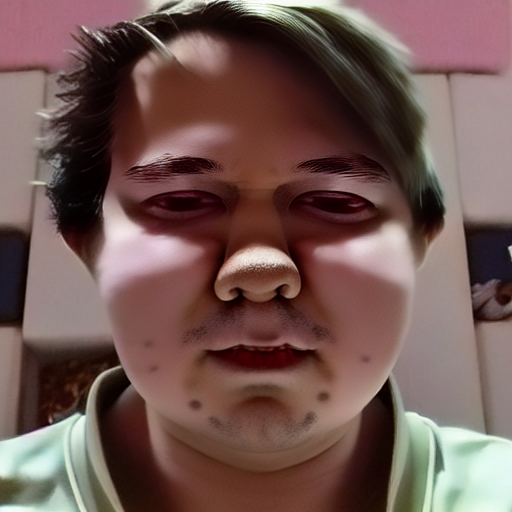

In [33]:
from IPython.display import Image as show
show("/content/selfie_4.png")